In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR

In [2]:
prices = pd.read_csv("Global_Commodity_Prices_2000_2026.csv")
oil_prices = prices.loc[prices["Commodity"] == "Crude Oil WTI", ["Date", "Close"]].copy()
oil_prices["Date"] = pd.to_datetime(oil_prices["Date"])
oil_prices = oil_prices.sort_values("Date").reset_index(drop=True)
oil_prices.head()

,Date,Close
0,2000-08-23,32.049999
1,2000-08-24,31.629999
2,2000-08-25,32.049999
3,2000-08-28,32.869999
4,2000-08-29,32.720001


In [3]:
pbr  = pd.read_csv("Petrobras Historical Stock Data (2000-2026).csv")
pbr  = pbr [["Date", "Close", "Open"]].copy()
pbr ["Date"] = pd.to_datetime(pbr ["Date"], errors="coerce")
pbr  = pbr .dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
pbr 

,Date,Close,Open
0,2000-08-10,1.254158,1.106288
1,2000-08-11,1.251420,1.199391
2,2000-08-14,1.245943,1.232251
3,2000-08-15,1.251420,1.245943
4,2000-08-16,1.284280,1.262373
...,...,...,...
6425,2026-03-02,17.320000,17.100000
6426,2026-03-03,16.959999,17.000000
6427,2026-03-04,16.770000,16.820000
6428,2026-03-05,16.730000,16.670000


In [4]:
merged = (
    pd.merge(
        pbr [["Date", "Close"]].rename(columns={"Close": "pbr"}),
        oil_prices[["Date", "Close"]].rename(columns={"Close": "WTI"}),
        on="Date",
        how="inner"
    )
    .dropna()
    .reset_index(drop=True)
)

print(merged.head())

        Date       pbr        WTI
0 2000-08-23  1.319878  32.049999
1 2000-08-24  1.292495  31.629999
2 2000-08-25  1.325354  32.049999
3 2000-08-28  1.319878  32.869999
4 2000-08-29  1.363692  32.720001


In [5]:
#0 = Período intervencionista (ex.: antes de out/2016).

#1 = PPI (Política de Paridade) – out/2016 a dez/2022.

#2 = Nova política (2023 em diante).
merged["Regime"] = np.select(
    [
        merged["Date"] < "2016-10-01",
        (merged["Date"] >= "2016-10-01") & (merged["Date"] < "2023-01-01"),
        merged["Date"] >= "2023-01-01"
    ],
    [0, 1, 2],
    default=np.nan
)

merged["Regime"] = merged["Regime"].astype("Int64")

In [6]:
merged

,Date,pbr,WTI,Regime
0,2000-08-23,1.319878,32.049999,0
1,2000-08-24,1.292495,31.629999,0
2,2000-08-25,1.325354,32.049999,0
3,2000-08-28,1.319878,32.869999,0
4,2000-08-29,1.363692,32.720001,0
...,...,...,...,...
6401,2026-03-02,17.320000,71.230003,2
6402,2026-03-03,16.959999,74.559998,2
6403,2026-03-04,16.770000,74.660004,2
6404,2026-03-05,16.730000,81.010002,2


In [7]:
merged.describe()

,Date,pbr,WTI,Regime
count,6406,6406.000000,6406.000000,6406.0
mean,2013-06-05 19:30:01.685919488,5.512710,64.664243,0.493756
min,2000-08-23 00:00:00,0.455562,-37.630001,0.0
25%,2007-01-29 06:00:00,2.426920,46.407501,0.0
50%,2013-06-08 12:00:00,4.487801,63.645000,0.0
75%,2019-10-20 06:00:00,8.105385,81.795002,1.0
max,2026-03-06 00:00:00,18.265079,145.289993,2.0
std,NaN,3.953508,24.512456,0.706085


In [8]:
merged["pbr_base100"] = merged["pbr"] / merged["pbr"].iloc[0] * 100
merged["WTI_base100"] = merged["WTI"] / merged["WTI"].iloc[0] * 100

In [9]:
merged

,Date,pbr,WTI,Regime,pbr_base100,WTI_base100
0,2000-08-23,1.319878,32.049999,0,100.000000,100.000000
1,2000-08-24,1.292495,31.629999,0,97.925331,98.689547
2,2000-08-25,1.325354,32.049999,0,100.414950,100.000000
3,2000-08-28,1.319878,32.869999,0,100.000000,102.558501
4,2000-08-29,1.363692,32.720001,0,103.319555,102.090490
...,...,...,...,...,...,...
6401,2026-03-02,17.320000,71.230003,2,1312.242845,222.246506
6402,2026-03-03,16.959999,74.559998,2,1284.967543,232.636503
6403,2026-03-04,16.770000,74.660004,2,1270.572373,232.948535
6404,2026-03-05,16.730000,81.010002,2,1267.541720,252.761323


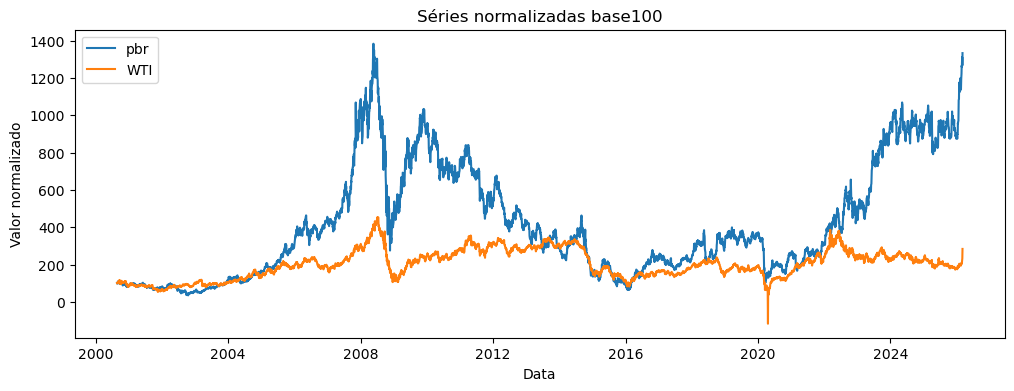

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(merged["Date"], merged["pbr_base100"], label="pbr")
plt.plot(merged["Date"], merged["WTI_base100"], label="WTI")
plt.title("Séries normalizadas base100")
plt.xlabel("Data")
plt.ylabel("Valor normalizado")
plt.legend()
plt.show()

In [11]:
merged["pbr_mm"] = (
    merged["pbr"] - merged["pbr"].min()
) / (
    merged["pbr"].max() - merged["pbr"].min()
)

In [12]:
merged["WTI_mm"] = (
    merged["WTI"] - merged["WTI"].min()
) / (
    merged["WTI"].max() - merged["WTI"].min()
)

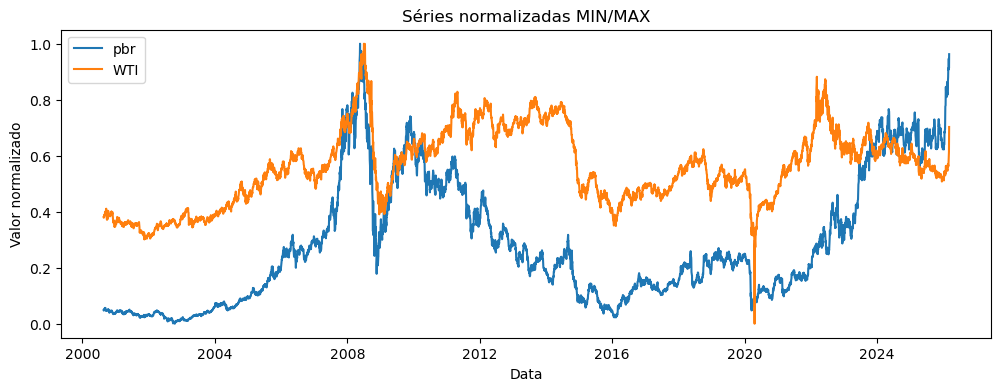

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(merged["Date"], merged["pbr_mm"], label="pbr")
plt.plot(merged["Date"], merged["WTI_mm"], label="WTI")
plt.title("Séries normalizadas MIN/MAX")
plt.xlabel("Data")
plt.ylabel("Valor normalizado")
plt.legend()
plt.show()

In [14]:
merged["pbr_ret"] = merged["pbr"].pct_change()
merged["WTI_ret"] = merged["WTI"].pct_change()

In [15]:
merged

,Date,pbr,WTI,Regime,pbr_base100,WTI_base100,pbr_mm,WTI_mm,pbr_ret,WTI_ret
0,2000-08-23,1.319878,32.049999,0,100.000000,100.000000,0.048531,0.380932,NaN,NaN
1,2000-08-24,1.292495,31.629999,0,97.925331,98.689547,0.046994,0.378635,-0.020747,-0.013105
2,2000-08-25,1.325354,32.049999,0,100.414950,100.000000,0.048839,0.380932,0.025424,0.013279
3,2000-08-28,1.319878,32.869999,0,100.000000,102.558501,0.048531,0.385414,-0.004132,0.025585
4,2000-08-29,1.363692,32.720001,0,103.319555,102.090490,0.050991,0.384594,0.033196,-0.004563
...,...,...,...,...,...,...,...,...,...,...
6401,2026-03-02,17.320000,71.230003,2,1312.242845,222.246506,0.946934,0.595124,0.041491,0.062817
6402,2026-03-03,16.959999,74.559998,2,1284.967543,232.636503,0.926720,0.613328,-0.020785,0.046750
6403,2026-03-04,16.770000,74.660004,2,1270.572373,232.948535,0.916052,0.613875,-0.011203,0.001341
6404,2026-03-05,16.730000,81.010002,2,1267.541720,252.761323,0.913806,0.648590,-0.002385,0.085052


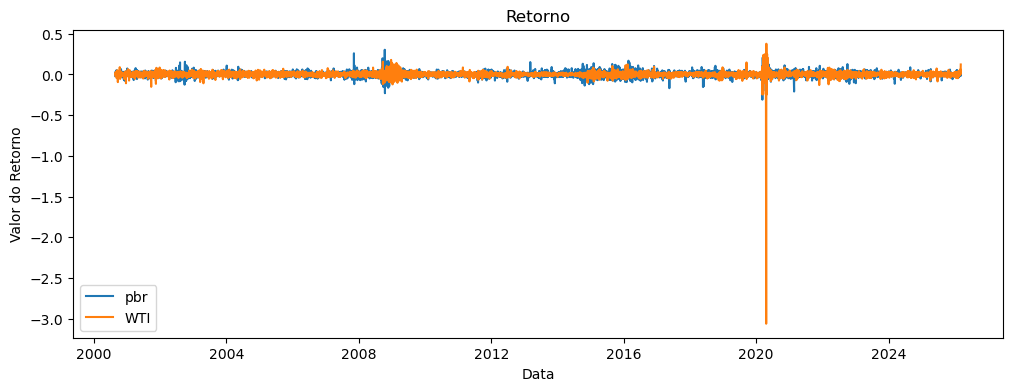

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(merged["Date"], merged["pbr_ret"], label="pbr")
plt.plot(merged["Date"], merged["WTI_ret"], label="WTI")
plt.title("Retorno")
plt.xlabel("Data")
plt.ylabel("Valor do Retorno")
plt.legend()
plt.show()

In [17]:
merged.describe()

,Date,pbr,WTI,Regime,pbr_base100,WTI_base100,pbr_mm,WTI_mm,pbr_ret,WTI_ret
count,6406,6406.000000,6406.000000,6406.0,6406.000000,6406.000000,6406.000000,6406.000000,6405.000000,6405.000000
mean,2013-06-05 19:30:01.685919488,5.512710,64.664243,0.493756,417.668301,201.760513,0.283958,0.559229,0.000894,-0.000084
min,2000-08-23 00:00:00,0.455562,-37.630001,0.0,34.515486,-117.410303,0.000000,0.000000,-0.309886,-3.059661
25%,2007-01-29 06:00:00,2.426920,46.407501,0.0,183.874627,144.797199,0.110691,0.459422,-0.014819,-0.012617
50%,2013-06-08 12:00:00,4.487801,63.645000,0.0,340.016470,198.580349,0.226409,0.553657,0.001147,0.001052
75%,2019-10-20 06:00:00,8.105385,81.795002,1.0,614.101238,255.210621,0.429536,0.652881,0.016422,0.013507
max,2026-03-06 00:00:00,18.265079,145.289993,2.0,1383.846438,453.322923,1.000000,1.000000,0.302682,0.376623
std,NaN,3.953508,24.512456,0.706085,299.535953,76.481925,0.221988,0.134006,0.031215,0.048839


In [18]:
returns = (
    merged[["Date", "pbr_ret", "WTI_ret", "Regime"]]
    .dropna()
    .reset_index(drop=True)
)

returns

,Date,pbr_ret,WTI_ret,Regime
0,2000-08-24,-0.020747,-0.013105,0
1,2000-08-25,0.025424,0.013279,0
2,2000-08-28,-0.004132,0.025585,0
3,2000-08-29,0.033196,-0.004563,0
4,2000-08-30,0.036144,0.020782,0
...,...,...,...,...
6400,2026-03-02,0.041491,0.062817,2
6401,2026-03-03,-0.020785,0.046750,2
6402,2026-03-04,-0.011203,0.001341,2
6403,2026-03-05,-0.002385,0.085052,2


In [19]:
def adf_report(series, name):
    result = adfuller(series.dropna())
    print(f"--- {name} ---")
    print(f"Estatística ADF: {result[0]:.4f}")
    print(f"p-valor: {result[1]:.4f}")
    print(f"Estacionária a 5%? {'SIM' if result[1] < 0.05 else 'NÃO'}")
    print()

In [20]:
adf_report(merged["pbr_base100"], "pbr normalizado (nível)")
adf_report(merged["WTI_base100"], "WTI normalizado (nível)")
adf_report(returns["pbr_ret"], "pbr (retornos)")
adf_report(returns["WTI_ret"], "WTI (retornos)")

--- pbr normalizado (nível) ---
Estatística ADF: -0.9019
p-valor: 0.7873
Estacionária a 5%? NÃO

--- WTI normalizado (nível) ---
Estatística ADF: -2.8783
p-valor: 0.0479
Estacionária a 5%? SIM

--- pbr (retornos) ---
Estatística ADF: -19.1578
p-valor: 0.0000
Estacionária a 5%? SIM

--- WTI (retornos) ---
Estatística ADF: -14.7759
p-valor: 0.0000
Estacionária a 5%? SIM



In [21]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

dados = merged[["pbr", "WTI"]].dropna()
resultado = coint_johansen(
    dados,
    det_order=0,
    k_ar_diff=5
)

In [22]:
print(resultado.lr1)

[13.00028066  1.21700417]


In [23]:
print(resultado.cvt)

[[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


In [24]:
regime_0 = merged[merged["Regime"] == 0].copy()
regime_1 = merged[merged["Regime"] == 1].copy()
regime_2 = merged[merged["Regime"] == 2].copy()

In [25]:
regime_0.reset_index(drop=True)
regime_1.reset_index(drop=True)
regime_2.reset_index(drop=True)

,Date,pbr,WTI,Regime,pbr_base100,WTI_base100,pbr_mm,WTI_mm,pbr_ret,WTI_ret
0,2023-01-03,5.777776,76.930000,2,437.750869,240.031208,0.298841,0.626285,-0.107981,-0.041490
1,2023-01-04,5.905494,72.839996,2,447.427406,227.269885,0.306012,0.603925,0.022105,-0.053165
2,2023-01-05,6.160933,73.669998,2,466.780624,229.859594,0.320355,0.608463,0.043254,0.011395
3,2023-01-06,6.252161,73.769997,2,473.692478,230.171602,0.325478,0.609009,0.014807,0.001357
4,2023-01-09,6.227834,74.629997,2,471.849331,232.854911,0.324112,0.613711,-0.003891,0.011658
...,...,...,...,...,...,...,...,...,...,...
791,2026-03-02,17.320000,71.230003,2,1312.242845,222.246506,0.946934,0.595124,0.041491,0.062817
792,2026-03-03,16.959999,74.559998,2,1284.967543,232.636503,0.926720,0.613328,-0.020785,0.046750
793,2026-03-04,16.770000,74.660004,2,1270.572373,232.948535,0.916052,0.613875,-0.011203,0.001341
794,2026-03-05,16.730000,81.010002,2,1267.541720,252.761323,0.913806,0.648590,-0.002385,0.085052


In [26]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

dados_regime_0 = regime_0[["pbr", "WTI"]].dropna()
resultado_0 = coint_johansen(
    dados_regime_0,
    det_order=0,
    k_ar_diff=5
)
dados_regime_1 = regime_1[["pbr", "WTI"]].dropna()
resultado_1 = coint_johansen(
    dados_regime_1,
    det_order=0,
    k_ar_diff=5
)
dados_regime_2 = regime_2[["pbr", "WTI"]].dropna()
resultado_2 = coint_johansen(
    dados_regime_2,
    det_order=0,
    k_ar_diff=5
)

In [27]:
print(resultado_0.lr1)

[15.18853164  5.09847167]


In [28]:
print(resultado_0.cvt)

[[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


In [29]:
print(resultado_1.lr1)

[11.41874319  2.6699085 ]


In [30]:
print(resultado_1.cvt)

[[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


In [31]:
print(resultado_2.lr1)

[9.31158366 4.04746293]


In [32]:
print(resultado_2.cvt)

[[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


In [33]:
trace = resultado.lr1
critical = resultado.cvt

print("Trace:", trace[0])
print("Crítico 95%:", critical[0,1])

if trace[0] > critical[0,1]:
    print("Existe cointegração")
else:
    print("Não existe cointegração")

Trace: 13.000280659583026
Crítico 95%: 15.4943
Não existe cointegração


In [34]:
trace = resultado_0.lr1
critical = resultado_0.cvt

print("Trace:", trace[0])
print("Crítico 95%:", critical[0,1])

if trace[0] > critical[0,1]:
    print("Existe cointegração")
else:
    print("Não existe cointegração")

Trace: 15.1885316378914
Crítico 95%: 15.4943
Não existe cointegração


In [35]:
trace = resultado_1.lr1
critical = resultado_1.cvt

print("Trace:", trace[0])
print("Crítico 95%:", critical[0,1])

if trace[0] > critical[0,1]:
    print("Existe cointegração")
else:
    print("Não existe cointegração")

Trace: 11.418743191516615
Crítico 95%: 15.4943
Não existe cointegração


In [36]:
trace = resultado_2.lr1
critical = resultado_2.cvt

print("Trace:", trace[0])
print("Crítico 95%:", critical[0,1])

if trace[0] > critical[0,1]:
    print("Existe cointegração")
else:
    print("Não existe cointegração")

Trace: 9.311583664084955
Crítico 95%: 15.4943
Não existe cointegração


In [37]:
dados = merged[["WTI_ret", "pbr_ret"]].dropna()

In [38]:
import statsmodels.api as sm

X = sm.add_constant(dados["WTI_ret"])
y = dados["pbr_ret"]

modelo_total = sm.OLS(y, X).fit()

print(modelo_total.summary())

                            OLS Regression Results                            
Dep. Variable:                pbr_ret   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     319.6
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           8.67e-70
Time:                        00:56:29   Log-Likelihood:                 13273.
No. Observations:                6405   AIC:                        -2.654e+04
Df Residuals:                    6403   BIC:                        -2.653e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      2.379      0.0

In [39]:
dados_0 = regime_0[["WTI_ret", "pbr_ret"]].dropna()
dados_1 = regime_1[["WTI_ret", "pbr_ret"]].dropna()
dados_2 = regime_2[["WTI_ret", "pbr_ret"]].dropna()

In [40]:
X = sm.add_constant(dados_0["WTI_ret"])
y = dados_0["pbr_ret"]

modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                pbr_ret   R-squared:                       0.149
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     708.6
Date:                Wed, 15 Jul 2026   Prob (F-statistic):          5.54e-144
Time:                        00:56:29   Log-Likelihood:                 8473.9
No. Observations:                4038   AIC:                        -1.694e+04
Df Residuals:                    4036   BIC:                        -1.693e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.060      0.2

In [41]:
X = sm.add_constant(dados_1["WTI_ret"])
y = dados_1["pbr_ret"]

modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                pbr_ret   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     43.87
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           4.81e-11
Time:                        00:56:29   Log-Likelihood:                 3146.3
No. Observations:                1571   AIC:                            -6289.
Df Residuals:                    1569   BIC:                            -6278.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012      0.001      1.457      0.1

In [42]:
X = sm.add_constant(dados_2["WTI_ret"])
y = dados_2["pbr_ret"]

modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                pbr_ret   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.166
Method:                 Least Squares   F-statistic:                     159.3
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           2.05e-33
Time:                        00:56:29   Log-Likelihood:                 2034.8
No. Observations:                 796   AIC:                            -4066.
Df Residuals:                     794   BIC:                            -4056.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.001      1.979      0.0

In [43]:
X0 = sm.add_constant(dados_0["WTI_ret"])
y0 = dados_0["pbr_ret"]

modelo0 = sm.OLS(y0, X0).fit()

In [44]:
X1 = sm.add_constant(dados_1["WTI_ret"])
y1 = dados_1["pbr_ret"]

modelo1 = sm.OLS(y1, X1).fit()

In [45]:
dados_com_data = merged[["Date", "WTI_ret", "pbr_ret"]].dropna()
TotalT = dados_com_data[~dados_com_data["Date"].isin(regime_2["Date"])]

In [46]:
X_pool01 = sm.add_constant(TotalT["WTI_ret"])
y_pool01 = TotalT["pbr_ret"]

modelo_totalT = sm.OLS(y_pool01, X_pool01).fit()

In [47]:
RSS_total = modelo_totalT.ssr
RSS0 = modelo0.ssr
RSS1 = modelo1.ssr

In [48]:
n0 = len(regime_0)
n1 = len(regime_1)

k = 2

In [49]:
F = (
    (RSS_total - (RSS0 + RSS1)) / k
) / (
    (RSS0 + RSS1) / (n0 + n1 - 2*k)
)

print(F)

217.66178625239536


In [50]:
from scipy.stats import f

p = 1 - f.cdf(F, k, n0+n1-2*k)

print(F)
print(p)

217.66178625239536
1.1102230246251565e-16
